# 리텐션 분석 — Dacon 이커머스 데이터셋

## 분석 개요

고객의 **첫 구매 월(코호트)** 을 기준으로, 이후 월별 재구매율을 분석한다.

| 섹션 | 내용 |
|------|------|
| 1 | 데이터 로드 및 코호트 구성 |
| 2 | 월별 최근·저빈도 고객 수 |
| 3 | 코호트 리텐션 분석 (히트맵 · 코호트별 추이 · 평균 추이) |
| 4 | 마케팅 비용과 재구매율 |
| 5 | 카테고리별 리텐션 분석 |

> **리텐션 정의**: 코호트 월에 구매한 고객 중, 이후 +N개월에도 구매한 고객의 비율  
> **데이터 한계**: 2019년 1년치 데이터만 존재하므로, 관측기간 첫 구매월은 데이터 내 최초 구매월 기준으로 처리  
> → 초기 코호트(1-2월)일수록 추적 가능한 기간이 길어 더 신뢰도 높은 리텐션 측정 가능

---
## 0. 환경 설정

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sqlalchemy import URL, create_engine
from dotenv import load_dotenv
import os
from pathlib import Path

PROJECT_ROOT = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / '.env').exists() and (path / 'sql').is_dir()
)
load_dotenv(PROJECT_ROOT / '.env')

db_url = URL.create(
    'mysql+mysqlconnector',
    username=os.getenv('DB_USER'),
    password=os.getenv('DB_PASSWORD'),
    host=os.getenv('DB_HOST'),
    database=os.getenv('DB_NAME'),
)
engine = create_engine(db_url)

# 분석 SQL은 ../sql/02_retention.sql 에 모으고 `-- name:` 마커로 구분한다.
import re
from pathlib import Path

SQL_FILE = PROJECT_ROOT / 'sql' / '02_retention.sql'

def load_queries(path):
    """`-- name: 이름 | 설명` 마커로 SQL을 쪼개 {이름: 쿼리}로 반환."""
    body = Path(path).read_text(encoding='utf-8')
    parts = re.split(r'(?m)^--\s*name:\s*(\w+).*$', body)
    return {parts[i]: parts[i + 1].strip() for i in range(1, len(parts), 2)}

Q = load_queries(SQL_FILE)

def run(name, **kwargs):
    """이름으로 SELECT 쿼리를 실행해 DataFrame 반환."""
    return pd.read_sql(Q[name], engine, **kwargs)

---
## 1. 데이터 로드 및 코호트 구성

In [2]:
# 고객별 월별 구매 이력 — 전체 관측기간 첫 구매월(first_month)과 경과월(month_diff) 포함
df = run('monthly_history')

df.head()

,고객ID,월,first_month,month_diff
0,USER_1358,1,1,0
1,USER_1358,1,1,0
2,USER_1358,1,1,0
3,USER_1358,1,1,0
4,USER_1358,1,1,0


In [3]:
# 고객-월 단위 중복 제거 (같은 달에 여러 거래 → 1건으로)
df = df.drop_duplicates(subset=['고객ID', '월'])

print(f"고유 고객 수: {df['고객ID'].nunique():,}명")
print(f"데이터 행 수: {len(df):,}건")

고유 고객 수: 1,468명
데이터 행 수: 2,578건


>전체 고객(1,468명)이 구매한 월의 수는 총 2,577개, **1인당 평균 1.76개월(12개월 중)** 에만 구매가 발생한 셈이다.  
대부분의 고객이 한 달 내지 두 달만 구매하고 장기적으로 재방문하지 않는 패턴임을 시사한다.

---
## 2. 월별 최근·저빈도 고객 수

In [4]:
# 월별 코호트 크기 — 해당 월에 첫 구매한 최근·저빈도 고객 수
cohort_size = run('cohort_size')
cohort_size

,월,cohort_size
0,1,215
1,2,96
2,3,177
3,4,163
4,5,112
5,6,137
6,7,94
7,8,135
8,9,78
9,10,87


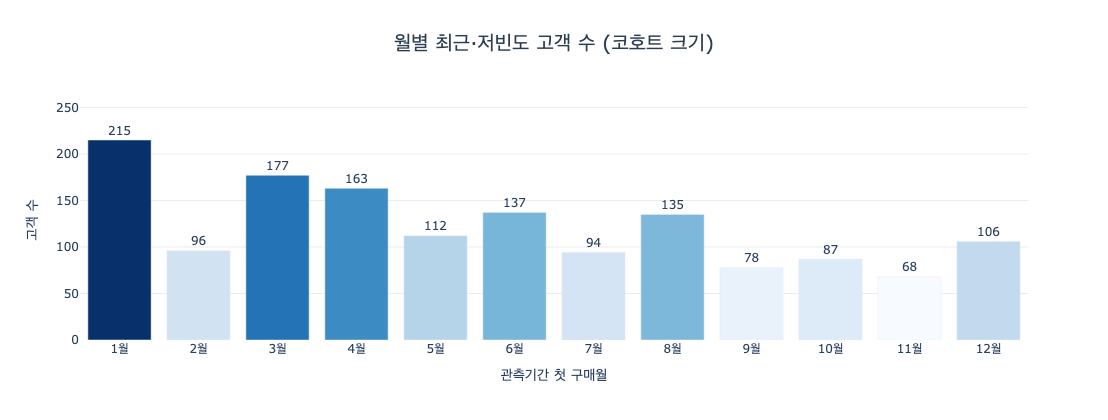

In [5]:
fig = go.Figure(go.Bar(
    x=[f'{m}월' for m in cohort_size['월']],
    y=cohort_size['cohort_size'],
    text=cohort_size['cohort_size'],
    textposition='outside',
    marker=dict(
        color=cohort_size['cohort_size'],
        colorscale='Blues',
        showscale=False
    )
))

fig.update_layout(
    title=dict(text='월별 최근·저빈도 고객 수 (코호트 크기)', x=0.5, xanchor='center',
               font=dict(size=20, color='#2c3e50')),
    xaxis_title='관측기간 첫 구매월',
    yaxis_title='고객 수',
    plot_bgcolor='white',
    yaxis=dict(gridcolor='#ececec',
               range=[0, cohort_size['cohort_size'].max() * 1.2]),
    height=420
)
fig.show()

### 인사이트

- 1월 신규 유입이 215명으로 연중 최다 — 연초 프로모션·신년 구매 수요가 집중된 것으로 보임
- 전반기(1-6월) 월평균 150명 vs 후반기(7-12월) 월평균 95명 — 하반기 신규 유입이 약 37% 감소
- 7·9·11월이 각각 93·78·68명으로 최저 구간 형성, 12월은 106명으로 소폭 반등
- 코호트 분석 시 초기 코호트(1-3월)는 표본이 크고 관측 기간이 길어 리텐션 신뢰도가 높으나, 후기 코호트는 표본 및 관측 기간 모두 짧아 해석에 주의가 필요함

---
## 3. 코호트 리텐션 분석

코호트 월 기준 최근·저빈도 고객 수(+0개월) 대비, 이후 +N개월에 재구매한 고객 비율을 히트맵·코호트별 추이·전체 평균 추이로 확인한다.

In [6]:
# 전체 코호트 집계
cohort_data = (
    df.groupby(["first_month", "month_diff"])["고객ID"]
    .nunique()
    .reset_index(name="customers")
)
cohort_pivot = cohort_data.pivot(index="first_month", columns="month_diff", values="customers")
cohort_pct = cohort_pivot.divide(cohort_pivot[0], axis=0).round(3) * 100

# ── 코호트 집계 ──
def build_cohort(df_sub):
    pivot = (
        df_sub.groupby(["first_month","month_diff"])["고객ID"]
        .nunique()
        .reset_index(name="customers")
        .pipe(lambda d: d.pivot(index="first_month", columns="month_diff", values="customers"))
    )
    pct = pivot.divide(pivot[0], axis=0).round(3) * 100
    return pivot, pct

# ── 코호트 히트맵 시각화 ──
def draw_cohort_heatmap(pivot, pct, title):
    hmap = pct.drop(columns=[0], errors="ignore")
    y_labels = [f"{i}월 코호트" for i in hmap.index]
    x_labels = [f"+{c}개월" for c in hmap.columns]
    sizes = pivot[0].reindex(hmap.index).values

    custom_text = [
        [f"{v:.1f}%" if (v == v and v > 0) else "" for v in row]
        for row in hmap.values
    ]

    fig = make_subplots(
        rows=1, cols=2,
        column_widths=[0.2, 0.8],
        subplot_titles=("Cohort Size", "Retention Heatmap (%)"),
        horizontal_spacing=0.04
    )
    fig.add_trace(go.Bar(
        x=sizes, y=y_labels, orientation="h",
        text=sizes, textposition="auto",
        marker_color="rgb(150,150,150)", showlegend=False
    ), row=1, col=1)
    fig.add_trace(go.Heatmap(
        z=hmap.values, x=x_labels, y=y_labels,
        colorscale="Blues", text=custom_text,
        texttemplate="%{text}", textfont=dict(size=12),
        colorbar=dict(title="Retention (%)"), zmin=0
    ), row=1, col=2)
    fig.update_yaxes(autorange="reversed")
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center",
                   font=dict(size=18, color="#2c3e50")),
        plot_bgcolor="white", width=1400, height=450,
        margin=dict(t=140)
    )
    fig.show()

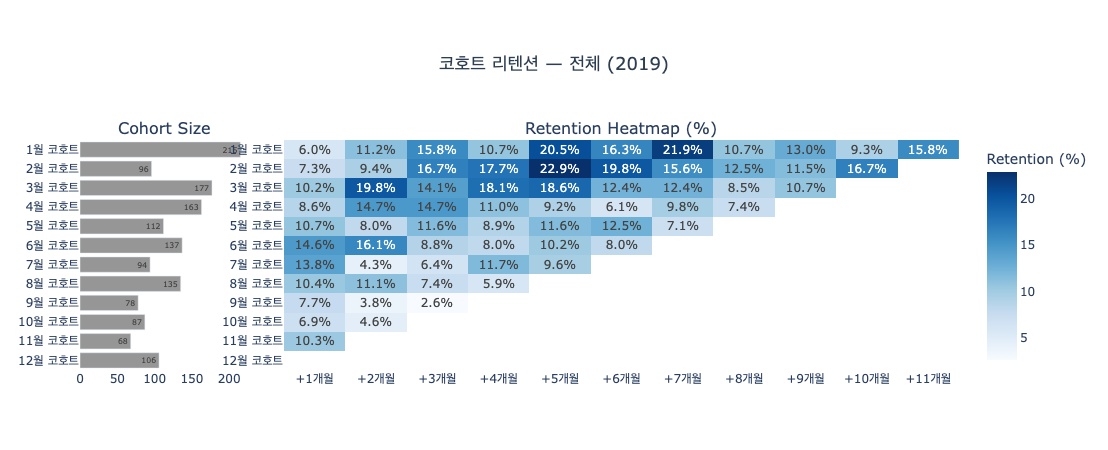

In [7]:
draw_cohort_heatmap(cohort_pivot, cohort_pct, "코호트 리텐션 — 전체 (2019)")

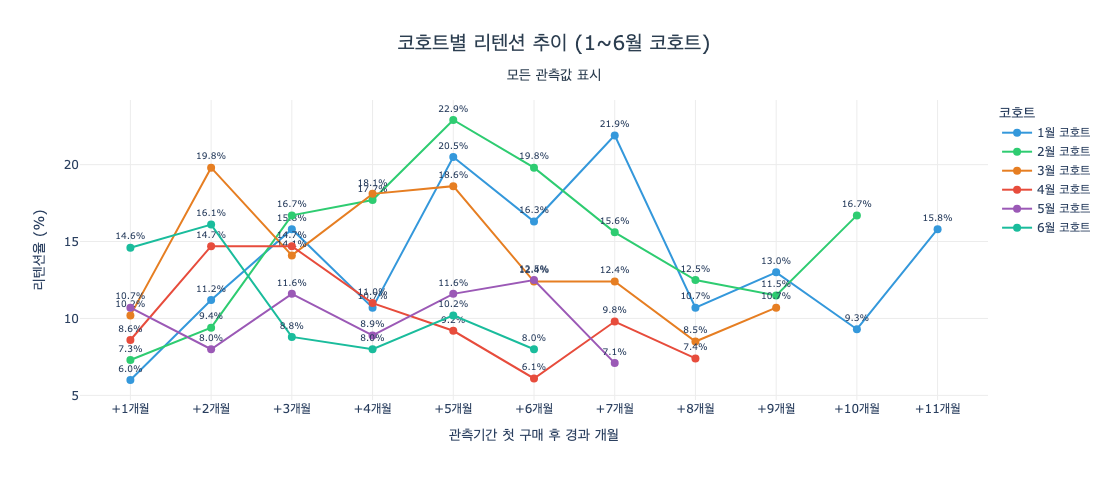

In [8]:
colors = ['#3498db', '#2ecc71', '#e67e22', '#e74c3c', '#9b59b6', '#1abc9c']
heatmap_vals = cohort_pct.drop(columns=[0], errors='ignore')
y_labels = [f'{i}월 코호트' for i in heatmap_vals.index]
early_cohorts = list(range(min(6, len(y_labels))))

fig = go.Figure()
for idx, cohort_idx in enumerate(early_cohorts):
    label = y_labels[cohort_idx]
    y_vals = heatmap_vals.iloc[cohort_idx].values
    x_vals = [f'+{c}개월' for c in heatmap_vals.columns]
    text_vals = [f'{v:.1f}%' if not np.isnan(v) else '' for v in y_vals]
    fig.add_trace(go.Scatter(
        x=x_vals, y=y_vals, mode='lines+markers+text', name=label,
        line=dict(color=colors[idx % len(colors)], width=2), marker=dict(size=8),
        text=text_vals, textposition='top center', textfont=dict(size=9),
        connectgaps=False,
    ))

fig.update_layout(
    title=dict(
        text='코호트별 리텐션 추이 (1~6월 코호트)<br><sub>모든 관측값 표시</sub>',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50'),
    ),
    xaxis_title='관측기간 첫 구매 후 경과 개월', yaxis_title='리텐션율 (%)',
    plot_bgcolor='white', xaxis=dict(gridcolor='#ececec'),
    yaxis=dict(gridcolor='#ececec'),
    legend=dict(title='코호트', orientation='v', x=1.01, y=1), height=480,
)
fig.show()


In [9]:
# 코호트 평균(각 코호트 동일 가중)과 고객 가중 리텐션을 함께 계산한다.
unweighted = cohort_pct.drop(columns=[0]).mean()
weighted = {}
for lag in cohort_pivot.columns.drop(0):
    eligible = cohort_pivot.index[cohort_pivot.index + lag <= 12]
    weighted[lag] = (
        cohort_pivot.loc[eligible, lag].sum()
        / cohort_pivot.loc[eligible, 0].sum()
        * 100
    )

avg_by_lag = pd.DataFrame({
    '경과월': unweighted.index,
    '코호트_단순평균': unweighted.values,
    '고객_가중리텐션': [weighted[lag] for lag in unweighted.index],
}).round(1)
avg_by_lag


,경과월,코호트_단순평균,고객_가중리텐션
0,1,9.7,9.5
1,2,10.3,11.5
2,3,10.9,11.8
3,4,11.5,11.5
4,5,14.7,15.1
5,6,12.5,12.3
6,7,13.4,14.2
7,8,9.8,9.5
8,9,11.7,11.9
9,10,13.0,11.6


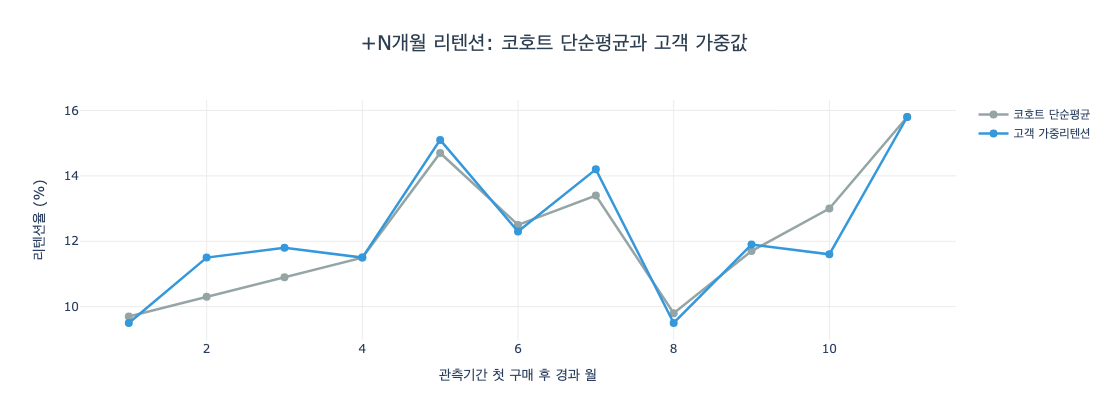

In [10]:
fig = go.Figure()
for metric, color in [('코호트_단순평균', '#95a5a6'), ('고객_가중리텐션', '#3498db')]:
    fig.add_trace(go.Scatter(
        x=avg_by_lag['경과월'], y=avg_by_lag[metric],
        mode='lines+markers', name=metric.replace('_', ' '),
        line=dict(color=color, width=2.5), marker=dict(size=8),
    ))
fig.update_layout(
    title=dict(
        text='+N개월 리텐션: 코호트 단순평균과 고객 가중값',
        x=0.5, xanchor='center', font=dict(size=20, color='#2c3e50'),
    ),
    xaxis=dict(title='관측기간 첫 구매 후 경과 월', gridcolor='#ececec'),
    yaxis=dict(title='리텐션율 (%)', gridcolor='#ececec'),
    plot_bgcolor='white', height=420,
)
fig.show()


### 해석

- 이 코호트는 실제 신규 획득 코호트가 아니라 **2019년 관측기간 첫 구매 코호트**다.
- +N개월 값은 달마다 변동하며, 1년치 데이터만으로 반복 주기나 계절성을 확정할 수 없다.
- 코호트 단순평균은 작은 코호트와 큰 코호트에 같은 가중치를 준다. 의사결정에는 고객 수로 가중한 리텐션을 함께 사용한다.
- 낮은 초기 복귀율은 재참여 실험의 근거가 될 수 있지만 신규 고객 온보딩 효과로 직접 해석하지 않는다.


---
## 4. 마케팅 비용과 재구매율

마케팅 비용 수준에 따라 유입된 고객의 재구매율을 비교한다.  
비용이 높은 날 유입된 고객이 장기적으로 더 높은 재구매율을 보이는지 확인한다.

> **가설**: 마케팅 비용이 높은 날 유입된 고객일수록 재구매율이 높을 것이다.

In [11]:
# 고객별 첫 구매일 기준 채널별 마케팅비용
cost_detail = run('first_purchase_cost')
cost_detail.head()

,고객ID,온라인비용,오프라인비용,총마케팅비용
0,USER_1358,2424.5,4500,6924.5
1,USER_0190,2424.5,4500,6924.5
2,USER_0066,2424.5,4500,6924.5
3,USER_0345,2424.5,4500,6924.5
4,USER_0683,2424.5,4500,6924.5


In [12]:
cost_detail.describe().round(2)

,온라인비용,오프라인비용,총마케팅비용
count,1468.00,1468.00,1468.00
mean,1888.93,2818.66,4707.60
std,808.82,1038.88,1541.12
min,320.25,500.00,820.25
25%,1253.24,2000.00,3767.58
50%,1827.02,3000.00,4668.34
75%,2432.58,3500.00,5553.41
max,4556.93,5000.00,8555.30


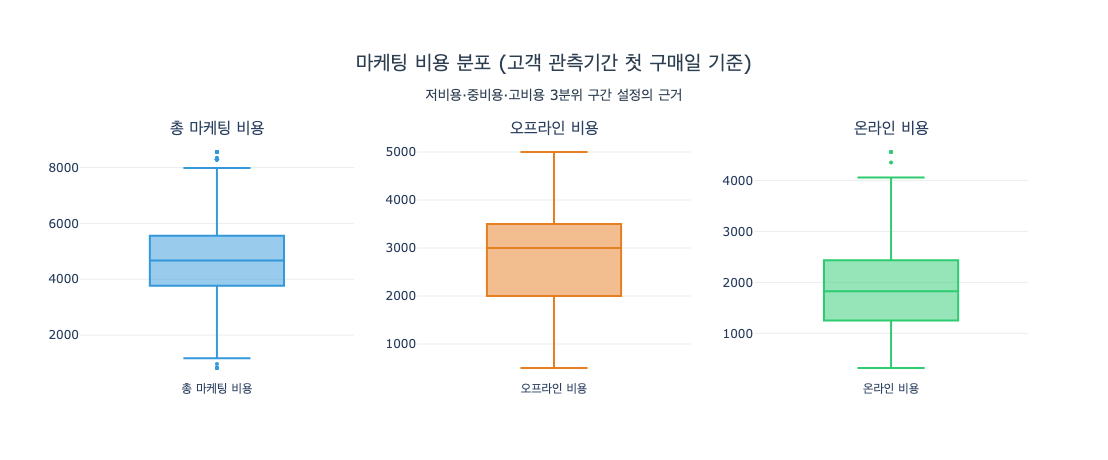

In [13]:
cols = [
    ("총마케팅비용", "총 마케팅 비용"),
    ("오프라인비용", "오프라인 비용"),
    ("온라인비용",  "온라인 비용"),
]
colors = ["#3498db", "#e67e22", "#2ecc71"]

fig = make_subplots(rows=1, cols=3, subplot_titles=[c[1] for c in cols])

for ci, (col, label) in enumerate(cols, 1):
    fig.add_trace(
        go.Box(
            y=cost_detail[col],
            name=label,
            boxpoints="outliers",
            marker=dict(color=colors[ci - 1], size=4),
            line=dict(color=colors[ci - 1]),
            showlegend=False,
        ),
        row=1, col=ci,
    )

fig.update_layout(
    title=dict(
        text="마케팅 비용 분포 (고객 관측기간 첫 구매일 기준)<br>"
             "<sub>저비용·중비용·고비용 3분위 구간 설정의 근거</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50"),
    ),
    plot_bgcolor="white",
    height=460,
    margin=dict(t=140)
)
fig.update_yaxes(gridcolor="#ececec")
fig.show()

In [14]:
cost_detail["비용구간"] = pd.qcut(
    cost_detail["총마케팅비용"], q=3,
    labels=["저비용","중비용","고비용"]
)

df_mkt_cohort = df.merge(cost_detail[["고객ID","비용구간"]], on="고객ID")

cohort_by_cost = {}
for seg in ["저비용","중비용","고비용"]:
    sub = df_mkt_cohort[df_mkt_cohort["비용구간"] == seg]
    cost_min = cost_detail[cost_detail["비용구간"] == seg]["총마케팅비용"].min()
    cost_max = cost_detail[cost_detail["비용구간"] == seg]["총마케팅비용"].max()
    pivot, pct = build_cohort(sub)
    cohort_by_cost[seg] = {"pivot": pivot, "pct": pct}
    print(f"{seg}: {sub['고객ID'].nunique()}명 / 마케팅 비용: {cost_min:,.0f} ~ {cost_max:,.0f}")

저비용: 489명 / 마케팅 비용: 820 ~ 4,189
중비용: 489명 / 마케팅 비용: 4,227 ~ 5,223
고비용: 490명 / 마케팅 비용: 5,231 ~ 8,555


In [15]:
cost_detail["오프라인구간"] = pd.qcut(
    cost_detail["오프라인비용"], q=3, labels=["저비용", "중비용", "고비용"]
)
cost_detail["온라인구간"] = pd.qcut(
    cost_detail["온라인비용"], q=3, labels=["저비용", "중비용", "고비용"]
)

cohort_by_offline = {}
df_offline = df.merge(cost_detail[["고객ID", "오프라인구간"]], on="고객ID")
for seg in ["저비용", "중비용", "고비용"]:
    sub = df_offline[df_offline["오프라인구간"] == seg]
    pivot, pct = build_cohort(sub)
    cohort_by_offline[seg] = {"pivot": pivot, "pct": pct}
    cost_min = cost_detail[cost_detail["오프라인구간"] == seg]["오프라인비용"].min()
    cost_max = cost_detail[cost_detail["오프라인구간"] == seg]["오프라인비용"].max()
    print(f"오프라인 {seg}: {sub['고객ID'].nunique()}명  ({cost_min:,.0f} ~ {cost_max:,.0f})")

print()

cohort_by_online = {}
df_online = df.merge(cost_detail[["고객ID", "온라인구간"]], on="고객ID")
for seg in ["저비용", "중비용", "고비용"]:
    sub = df_online[df_online["온라인구간"] == seg]
    pivot, pct = build_cohort(sub)
    cohort_by_online[seg] = {"pivot": pivot, "pct": pct}
    cost_min = cost_detail[cost_detail["온라인구간"] == seg]["온라인비용"].min()
    cost_max = cost_detail[cost_detail["온라인구간"] == seg]["온라인비용"].max()
    print(f"온라인 {seg}: {sub['고객ID'].nunique()}명  ({cost_min:,.0f} ~ {cost_max:,.0f})")

오프라인 저비용: 626명  (500 ~ 2,500)
오프라인 중비용: 363명  (3,000 ~ 3,000)
오프라인 고비용: 479명  (3,500 ~ 5,000)

온라인 저비용: 498명  (320 ~ 1,477)
온라인 중비용: 481명  (1,478 ~ 2,223)
온라인 고비용: 489명  (2,228 ~ 4,557)


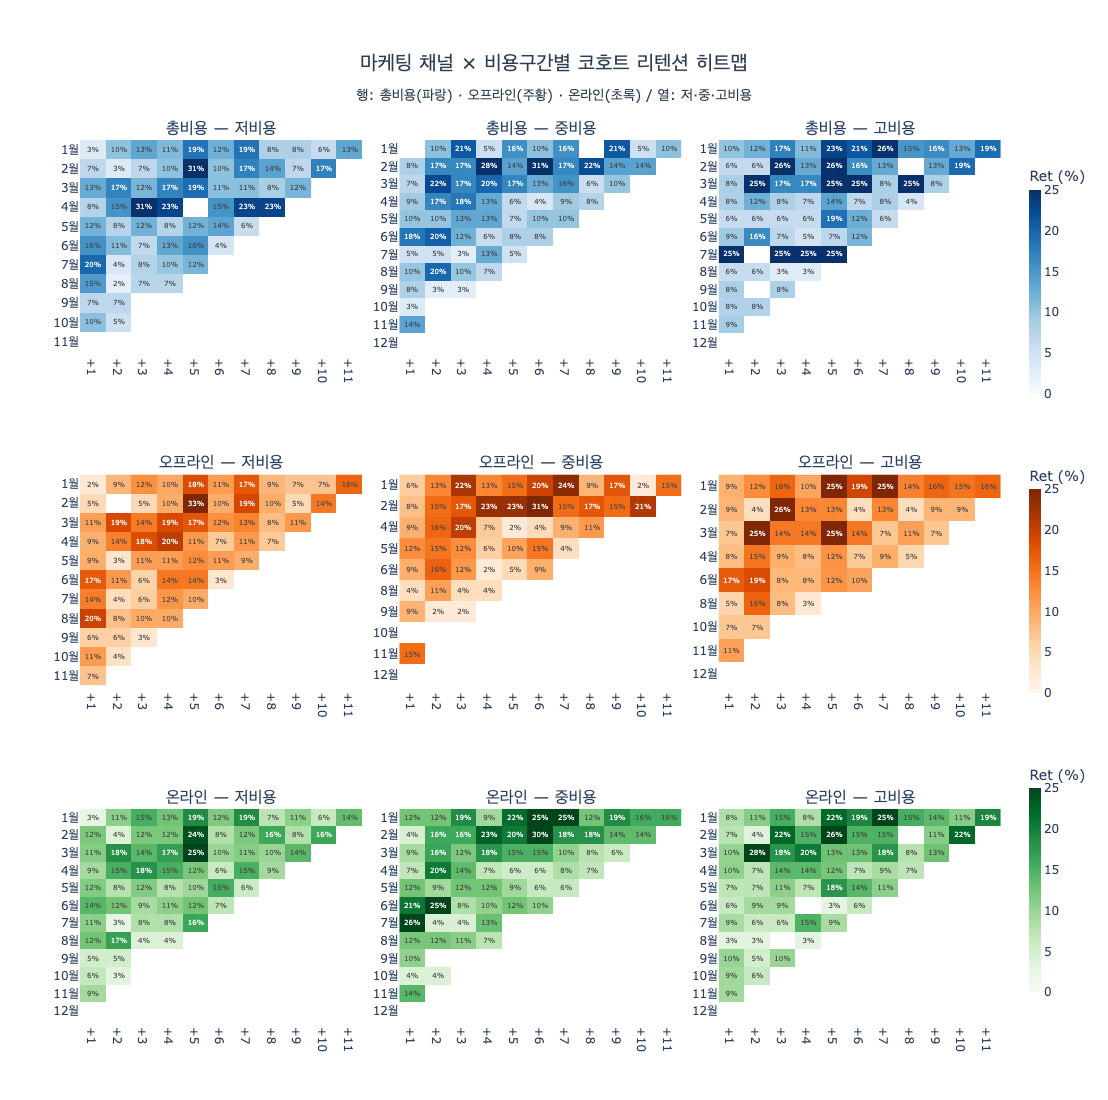

In [16]:
channel_data = [
    ("총비용",   cohort_by_cost,    "Blues"),
    ("오프라인", cohort_by_offline, "Oranges"),
    ("온라인",   cohort_by_online,  "Greens"),
]
segs = ["저비용", "중비용", "고비용"]
colorbar_y = {1: 0.84, 2: 0.50, 3: 0.16}

specs = [[{"type": "heatmap"}] * 3 for _ in range(3)]
subplot_titles = [
    f"{ch} — {seg}"
    for ch, _, __ in channel_data
    for seg in segs
]

fig = make_subplots(
    rows=3, cols=3,
    specs=specs,
    subplot_titles=subplot_titles,
    vertical_spacing=0.14,
    horizontal_spacing=0.04,
)

for ri, (channel, data_dict, colorscale) in enumerate(channel_data, 1):
    for ci, seg in enumerate(segs, 1):
        data = data_dict[seg]
        hmap = data["pct"].drop(columns=[0], errors="ignore")
        y_labels = [f"{i}월" for i in hmap.index]
        x_labels = [f"+{c}" for c in hmap.columns]
        custom_text = [
            [f"{v:.0f}%" if (v == v and v > 0) else "" for v in row]
            for row in hmap.values
        ]
        show_scale = (ci == 3)
        fig.add_trace(
            go.Heatmap(
                z=hmap.values,
                x=x_labels,
                y=y_labels,
                colorscale=colorscale,
                text=custom_text,
                texttemplate="%{text}",
                textfont=dict(size=7),
                showscale=show_scale,
                colorbar=dict(
                    x=1.02, len=0.28, y=colorbar_y[ri],
                    title=dict(text="Ret (%)"),
                    thickness=12,
                ),
                zmin=0,
                zmax=25,
            ),
            row=ri, col=ci,
        )

fig.update_yaxes(autorange="reversed")
fig.update_layout(
    title=dict(
        text="마케팅 채널 × 비용구간별 코호트 리텐션 히트맵<br>"
             "<sub>행: 총비용(파랑) · 오프라인(주황) · 온라인(초록) / 열: 저·중·고비용</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50"),
    ),
    plot_bgcolor="white",
    height=1100,
    width=1400,
    margin=dict(t=140),
)
fig.show()

### 해석

- 비용 구간별 리텐션 차이는 마케팅 원본의 일별 집행액과 같은 날 관측을 시작한 고객의 이후 행동 간 연관성이다.
- 고객별 실제 노출·채널·캠페인 ID가 없으므로 획득비용이나 캠페인 효과로 해석할 수 없다.
- qcut 구간과 중첩 코호트의 변동이 크므로 장기 값의 서열은 후속 실험 가설로만 사용한다.


---
## 5. 카테고리별 리텐션 분석

매출 상위 카테고리 구매 고객의 코호트 리텐션 히트맵과, 성별별 카테고리 재구매율 추이를 함께 확인한다.

| 분석 | 내용 |
|------|------|
| 히트맵 | 카테고리별 코호트 리텐션 (관측기간 첫 구매월 기준 잔존율) |
| 추이 A | 고객 관측기간 첫 구매월 기준 — 이후 월에도 구매(전 카테고리)한 비율 |
| 추이 B | 카테고리 관측기간 첫 구매월 기준 — 같은 카테고리를 재구매한 비율 |

In [17]:
# 매출 상위 5개 카테고리 — curve_a/curve_b SQL 내부 top_cats와 기준 통일 (고객 수 기준)
top_cats = run('top_categories')["제품카테고리"].tolist()

# 고객-카테고리-월 데이터
df_cat = run('category_history')

df_cat = df_cat.drop_duplicates(["고객ID", "월", "제품카테고리"])
top_cats

['Apparel', 'Nest-USA', 'Office', 'Drinkware', 'Lifestyle']

In [18]:
df_cat.head()

,고객ID,월,제품카테고리,first_month,month_diff
0,USER_1358,1,Nest-USA,1,0
2,USER_1358,1,Office,1,0
3,USER_1358,1,Apparel,1,0
4,USER_1358,1,Bags,1,0
6,USER_1358,1,Drinkware,1,0


In [19]:
cohort_by_cat = {}
for cat in top_cats:
    entry_rows = df_cat[df_cat['월'] == df_cat['first_month']]
    cat_customers = set(entry_rows[entry_rows['제품카테고리'] == cat]['고객ID'])
    df_sub = df_cat[df_cat["고객ID"].isin(cat_customers)]
    pivot, pct = build_cohort(df_sub)
    cohort_by_cat[cat] = {"pivot": pivot, "pct": pct}
    print(f"{cat}: {len(cat_customers)}명")

Apparel: 1245명
Nest-USA: 1181명
Office: 993명
Drinkware: 785명
Lifestyle: 668명


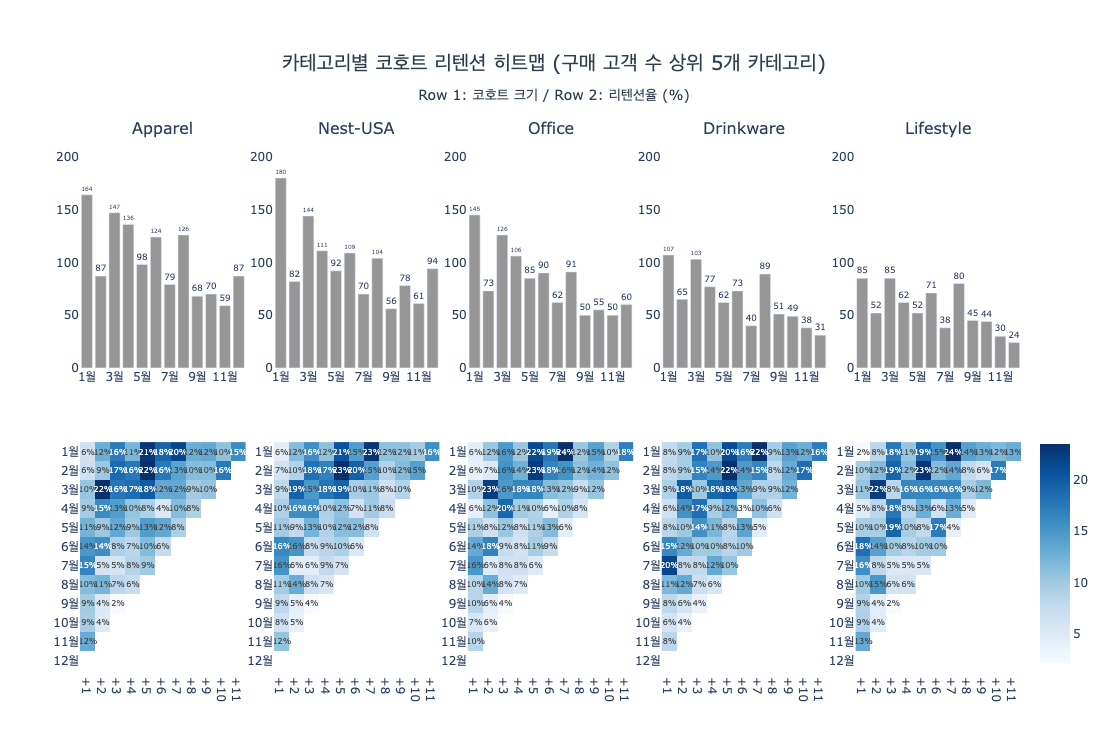

In [20]:
specs = [[{"type": "xy"}] * 5, [{"type": "heatmap"}] * 5]

fig = make_subplots(
    rows=2, cols=5,
    specs=specs,
    subplot_titles=top_cats,
    vertical_spacing=0.14,
    horizontal_spacing=0.03
)

max_size = max(data["pivot"][0].max() for data in cohort_by_cat.values())

for ci, cat in enumerate(top_cats, 1):
    data = cohort_by_cat[cat]
    hmap = data["pct"].drop(columns=[0], errors="ignore")
    sizes = data["pivot"][0].reindex(hmap.index).values
    cat_y = [f"{i}월" for i in hmap.index]
    cat_x = [f"+{c}" for c in hmap.columns]

    fig.add_trace(go.Bar(
        x=cat_y,
        y=sizes,
        text=sizes,
        textposition="outside",
        marker_color="rgb(150,150,150)",
        showlegend=False
    ), row=1, col=ci)

    fig.add_trace(go.Heatmap(
        z=hmap.values,
        x=cat_x,
        y=cat_y,
        colorscale="Blues",
        text=[[f"{v:.0f}%" if (v == v and v > 0) else "" for v in row] for row in hmap.values],
        texttemplate="%{text}",
        textfont=dict(size=8),
        showscale=(ci == 5),
        colorbar=dict(x=1.01, len=0.45, y=0.22),
        zmin=0
    ), row=2, col=ci)

fig.update_yaxes(range=[0, max_size * 1.2], row=1)
fig.update_yaxes(autorange="reversed", row=2)

fig.update_layout(
    title=dict(
        text="카테고리별 코호트 리텐션 히트맵 (구매 고객 수 상위 5개 카테고리)<br>"
             "<sub>Row 1: 코호트 크기 / Row 2: 리텐션율 (%)</sub>",
        x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")
    ),
    plot_bgcolor="white",
    height=750,
    width=1500,
    margin=dict(t=140)
)
fig.show()

In [21]:
# A/B 모두 관측기간 첫 구매월에 해당 카테고리를 산 고객을 같은 모집단으로 사용한다.
# A: 이후 월 전체 카테고리 복귀 / B: 이후 월 동일 카테고리 복귀
curve_a = run('curve_a')
curve_b = run('curve_b')

gender_top_cats = (
    curve_a.drop_duplicates(['성별', '제품카테고리'])[['성별', '제품카테고리']]
)
curve_a.head(10)


,성별,제품카테고리,구매후_경과월,재구매율
0,남,Apparel,1,9.9
1,남,Apparel,2,11.4
2,남,Apparel,3,11.9
3,남,Apparel,4,12.0
4,남,Apparel,5,13.9
5,남,Apparel,6,14.0
6,남,Apparel,7,15.9
7,남,Apparel,8,10.0
8,남,Apparel,9,12.2
9,남,Apparel,10,10.3


In [22]:
# 성별별 top1 카테고리 구매 고객의 코호트 리텐션 데이터 로드
# SQL은 sql/02_retention.sql(cohort_by_cat), 성별·카테고리만 .format으로 주입 (내부 DB·고정값)
top1_female = gender_top_cats[gender_top_cats["성별"] == "여"]["제품카테고리"].iloc[0]
top1_male = gender_top_cats[gender_top_cats["성별"] == "남"]["제품카테고리"].iloc[0]

cohort_top1 = {}
for gender, cat in [("여", top1_female), ("남", top1_male)]:
    df_sub = pd.read_sql(Q['cohort_by_cat'].format(gender=gender, cat=cat), engine)
    df_sub = df_sub.drop_duplicates(["고객ID", "월"])
    pivot, pct = build_cohort(df_sub)
    cohort_top1[gender] = {"pivot": pivot, "pct": pct, "cat": cat}
    print(f"{gender}성 top1 [{cat}]: {df_sub['고객ID'].nunique()}명")

여성 top1 [Apparel]: 784명
남성 top1 [Apparel]: 461명


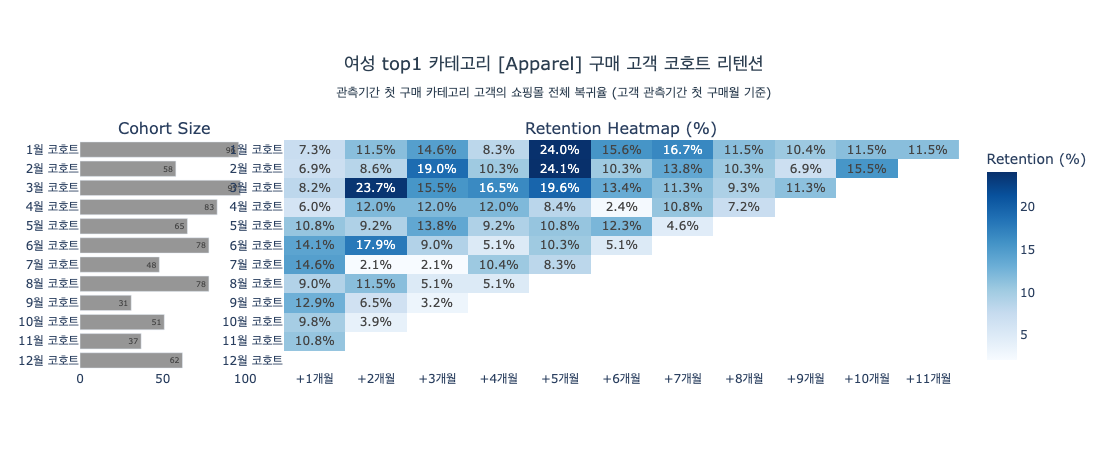

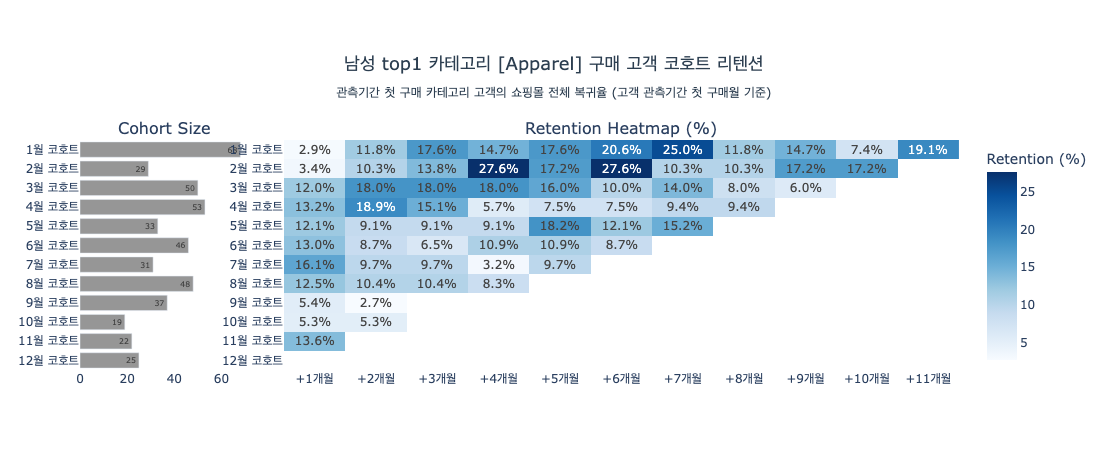

In [23]:
for gender, data in cohort_top1.items():
    label = "여성" if gender == "여" else "남성"
    draw_cohort_heatmap(
        data["pivot"], data["pct"],
        f"{label} top1 카테고리 [{data['cat']}] 구매 고객 코호트 리텐션"
        f"<br><sub>관측기간 첫 구매 카테고리 고객의 쇼핑몰 전체 복귀율 (고객 관측기간 첫 구매월 기준)</sub>"
    )

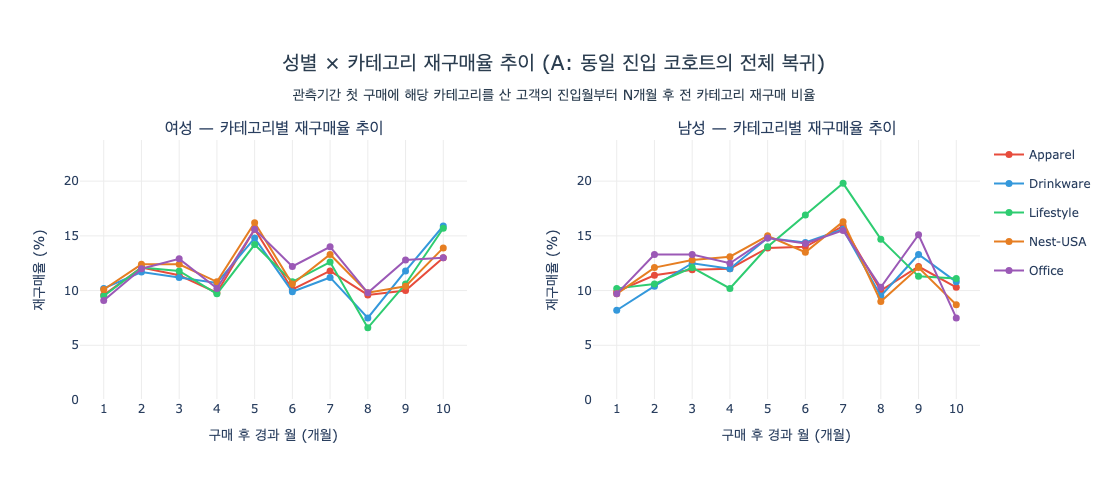

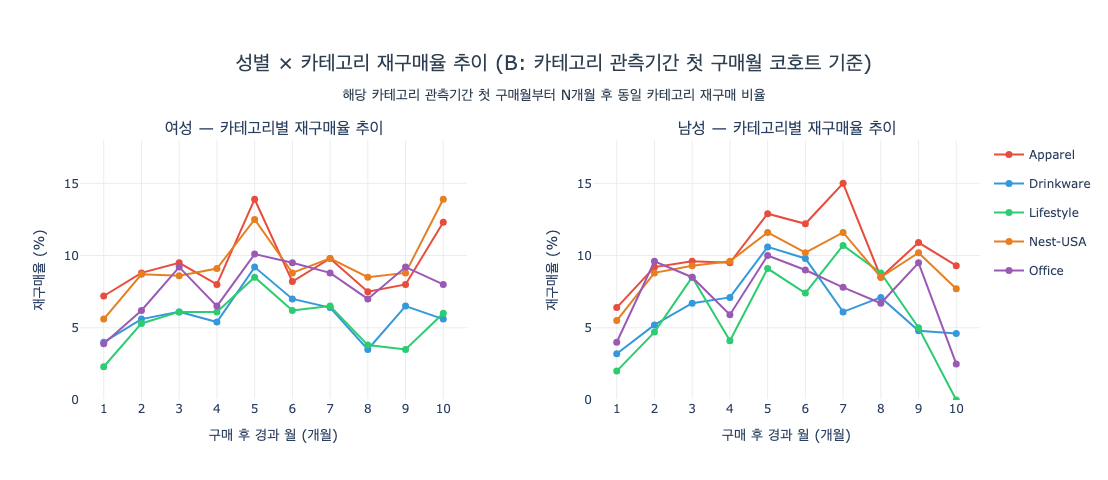

In [24]:
COLORS = ["#e74c3c", "#3498db", "#2ecc71", "#e67e22", "#9b59b6"]

def draw_retention_curve(curve, title):
    fig = make_subplots(
        rows=1, cols=2,
        subplot_titles=("여성 — 카테고리별 재구매율 추이", "남성 — 카테고리별 재구매율 추이"),
        horizontal_spacing=0.14
    )
    for col_idx, gender in enumerate(["여", "남"], 1):
        cats = gender_top_cats[gender_top_cats["성별"] == gender]["제품카테고리"].tolist()
        for ci, cat in enumerate(cats):
            sub = curve[(curve["성별"] == gender) & (curve["제품카테고리"] == cat)]
            fig.add_trace(go.Scatter(
                x=sub["구매후_경과월"],
                y=sub["재구매율"],
                mode="lines+markers",
                name=cat,
                line=dict(color=COLORS[ci % len(COLORS)], width=2),
                marker=dict(size=7),
                legendgroup=cat,
                showlegend=(col_idx == 1),
            ), row=1, col=col_idx)

    y_max = curve["재구매율"].max() * 1.2
    fig.update_layout(
        title=dict(text=title, x=0.5, xanchor="center", font=dict(size=20, color="#2c3e50")),
        plot_bgcolor="white", height=480, width=1000,
        legend=dict(orientation="v", x=1.01, y=1),
        margin=dict(t=140)
    )
    for i in range(1, 3):
        fig.update_xaxes(
            title_text="구매 후 경과 월 (개월)", tickvals=list(range(1, 11)),
            gridcolor="#ececec", row=1, col=i
        )
        fig.update_yaxes(
            title_text="재구매율 (%)", gridcolor="#ececec",
            range=[0, y_max], row=1, col=i
        )
    fig.show()

draw_retention_curve(
    curve_a,
    "성별 × 카테고리 재구매율 추이 (A: 동일 진입 코호트의 전체 복귀)<br>"
    "<sub>관측기간 첫 구매에 해당 카테고리를 산 고객의 진입월부터 N개월 후 전 카테고리 재구매 비율</sub>"
)
draw_retention_curve(
    curve_b,
    "성별 × 카테고리 재구매율 추이 (B: 카테고리 관측기간 첫 구매월 코호트 기준)<br>"
    "<sub>해당 카테고리 관측기간 첫 구매월부터 N개월 후 동일 카테고리 재구매 비율</sub>"
)

### 해석 — 전체 복귀 곡선 A

곡선 A는 **관측기간 첫 구매에 해당 카테고리가 포함된 고객**이 이후 월에 쇼핑몰
어느 카테고리에서든 다시 구매한 비율이다. 성별·카테고리별 국소 피크는 탐색값이며,
한 해의 작은 코호트 변동만으로 고정 재구매 주기를 확정하지 않는다.


#### 같은 카테고리 복귀 곡선 B

곡선 B는 곡선 A와 동일한 고객·동일한 진입월을 분모로 사용하고, 같은 카테고리로
복귀했는지만 측정한다. 따라서 두 곡선은 동일한 경과월에서 비교할 수 있다. 다만
불규칙한 국소 피크를 2개월·3개월 구매 주기로 단정하지 않고 실험 후보 시점으로만 사용한다.


#### 전체 복귀와 같은 카테고리 복귀의 차이

같은 고객·같은 진입월·같은 경과월에서 `A-B`는 쇼핑몰에는 복귀했지만 진입
카테고리에는 복귀하지 않은 고객 비중을 뜻한다. 이 차이는 카테고리 간 이동의
기술 통계이며 크로스셀의 인과 효과나 카테고리 충성도를 직접 입증하지 않는다.


#### 마케팅 제언

- 초기 복귀율이 낮은 구간을 대상으로 30/60일 재참여 시점을 무작위 실험으로 비교한다.
- 동일 카테고리 추천과 연관 카테고리 추천을 같은 모집단에서 A/B 테스트한다.
- 특정 월 피크는 다년도 데이터로 반복 여부를 확인한 뒤 운영 규칙으로 채택한다.


---
## 종합 인사이트

### 1. 전체 리텐션 수준

2019년 관측기간 첫 구매 코호트의 이후 월 복귀율은 전반적으로 낮다. 이는 재참여
실험의 필요성을 보여주지만 실제 신규 획득 코호트의 온보딩 성과를 의미하지 않는다.


### 2. 마케팅 집행액과 리텐션

집행액 구간과 장기 복귀율 사이에 일부 차이가 관찰되지만 고객별 광고 노출과 캠페인
식별자가 없어 효과나 ROI를 추정할 수 없다. 채널별 결과도 탐색값으로만 사용한다.


### 3. 복귀 시점

성별·카테고리별 곡선에 국소 피크가 있지만 1년치 작은 코호트에서 반복 주기를
확정하지 않는다. 피크 직전 시점은 A/B 테스트 후보로만 사용한다.


### 4. 전체 복귀와 같은 카테고리 복귀

두 곡선은 같은 진입 고객과 기준월을 사용하도록 수정했다. 같은 경과월의 차이는
다른 카테고리로 복귀한 비중을 기술하지만 크로스셀 효과나 충성도를 입증하지 않는다.


### 5. 통합 시사점

가장 안전한 결론은 관측 초기 복귀율이 낮고 고객별 복귀 시점의 변동이 크다는 것이다.
따라서 고정 캠페인 규칙보다 30/60일 재참여 시점과 동일/연관 카테고리 추천을 실험한다.


### 6. 실험 우선순위

| 우선순위 | 대상 | 비교할 실험 | 핵심 지표 |
|---|---|---|---|
| 1 | 관측기간 첫 구매 고객 | 30일 vs 60일 재참여 | 이후 30일 내 다른 날 재구매율 |
| 2 | 진입 카테고리 고객 | 동일 카테고리 vs 연관 카테고리 추천 | 카테고리·전체 재구매율 |
| 3 | 마케팅 적격 고객 | 채널·메시지 무작위 배정 | 증분 매출, 할인비용률, 수신거부율 |

집행 전 표본 수와 MDE를 계산하고 캠페인 ID·노출 로그·마진을 수집한다.
